In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 추정매출 데이터 로드
매출_파일들 = glob.glob('../data/03_추정매출/*.csv')
매출_리스트 = []
for 파일 in 매출_파일들:
    if '2025' in 파일:
        continue
    df = pd.read_csv(파일, encoding='cp949', low_memory=False)
    매출_리스트.append(df)

sales = pd.concat(매출_리스트, ignore_index=True)

# 유동인구 데이터 로드
floating = pd.read_csv(
    '../data/05_길단위인구/서울시 상권분석서비스(길단위인구-상권).csv',
    encoding='cp949'
)

print(f'추정매출: {sales.shape}')
print(f'유동인구: {floating.shape}')

추정매출: (435849, 62)
유동인구: (46184, 27)


In [8]:
# ============================================
# 파생 변수 준비
# ============================================

상권 = ['골목상권', '발달상권', '관광특구', '전통시장']

연령_매출 = [
    '연령대_10_매출_금액', '연령대_20_매출_금액', '연령대_30_매출_금액',
    '연령대_40_매출_금액', '연령대_50_매출_금액', '연령대_60_이상_매출_금액'
]
연령_유동 = [
    '연령대_10_유동인구_수', '연령대_20_유동인구_수', '연령대_30_유동인구_수',
    '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수'
]
연령라벨 = ['10대', '20대', '30대', '40대', '50대', '60대+']

# 상권 단위 합산
sales_demo = sales.groupby(
    ['기준_년분기_코드', '상권_코드', '상권_구분_코드_명']
)[연령_매출 + ['당월_매출_금액']].sum().reset_index()

# 유동인구 병합
merged_demo = sales_demo.merge(
    floating[['기준_년분기_코드', '상권_코드'] + 연령_유동 + ['총_유동인구_수']],
    on=['기준_년분기_코드', '상권_코드'],
    how='inner'
)

# 비중 계산
for i, 라벨 in enumerate(연령라벨):
    merged_demo[f'{라벨}_매출비중'] = (
        merged_demo[연령_매출[i]] / merged_demo['당월_매출_금액'] * 100
    )
    merged_demo[f'{라벨}_유동비중'] = (
        merged_demo[연령_유동[i]] / merged_demo['총_유동인구_수'].replace(0, np.nan) * 100
    )

print(f'병합 완료: {merged_demo.shape}')
print(f'상권 유형: {merged_demo["상권_구분_코드_명"].unique()}')

병합 완료: (31371, 29)
상권 유형: <StringArray>
['관광특구', '골목상권', '발달상권', '전통시장']
Length: 4, dtype: str


In [9]:
# ============================================
# 상권 유형별 연령대 매출비중 vs 유동비중
# ============================================

print('상권 유형별 연령대 매출비중 vs 유동비중')
print('=' * 60)

for 구분 in 상권:
    sub = merged_demo[merged_demo['상권_구분_코드_명'] == 구분]
    print(f'\n▶ {구분}')
    print(f'{"연령대":<6} {"매출비중":>8} {"유동비중":>8} {"갭":>8}')
    print('-' * 35)
    for 라벨 in 연령라벨:
        매출 = sub[f'{라벨}_매출비중'].mean()
        유동 = sub[f'{라벨}_유동비중'].mean()
        print(f'{라벨:<6} {매출:>7.1f}% {유동:>7.1f}% {매출-유동:>+7.1f}')

상권 유형별 연령대 매출비중 vs 유동비중

▶ 골목상권
연령대        매출비중     유동비중        갭
-----------------------------------
10대        0.5%    14.1%   -13.6
20대       10.6%    15.9%    -5.3
30대       16.9%    16.5%    +0.4
40대       22.7%    15.9%    +6.8
50대       22.0%    14.9%    +7.1
60대+      18.3%    22.6%    -4.3

▶ 발달상권
연령대        매출비중     유동비중        갭
-----------------------------------
10대        0.6%    11.7%   -11.1
20대       12.7%    18.4%    -5.7
30대       18.9%    19.9%    -1.0
40대       21.7%    17.9%    +3.7
50대       19.3%    14.3%    +5.0
60대+      15.2%    17.8%    -2.6

▶ 관광특구
연령대        매출비중     유동비중        갭
-----------------------------------
10대        0.6%     5.8%    -5.2
20대       17.0%    20.3%    -3.2
30대       22.7%    24.0%    -1.3
40대       18.7%    19.3%    -0.6
50대       15.8%    14.5%    +1.3
60대+      14.8%    16.1%    -1.3

▶ 전통시장
연령대        매출비중     유동비중        갭
-----------------------------------
10대        0.4%    11.4%   -11.0
20대        8.6%    16.4%    -7.8
30대 

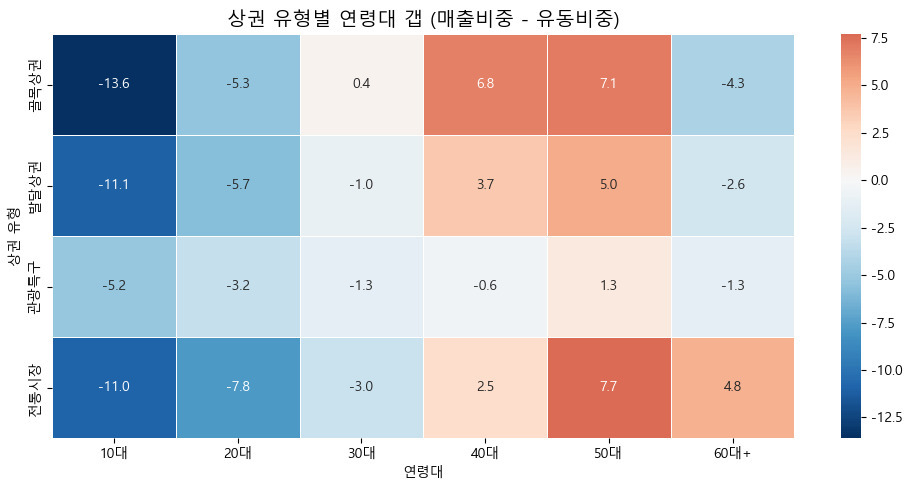

In [10]:
# ============================================
# 상권 유형별 연령대 갭 히트맵
# ============================================

갭_data = []
for 구분 in 상권:
    sub = merged_demo[merged_demo['상권_구분_코드_명'] == 구분]
    row = []
    for 라벨 in 연령라벨:
        매출 = sub[f'{라벨}_매출비중'].mean()
        유동 = sub[f'{라벨}_유동비중'].mean()
        row.append(round(매출 - 유동, 1))
    갭_data.append(row)

갭_df = pd.DataFrame(갭_data, index=상권, columns=연령라벨)

fig, ax = plt.subplots(figsize=(10, 5))

sns.heatmap(
    갭_df,
    annot=True,
    fmt='.1f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    ax=ax
)

ax.set_title('상권 유형별 연령대 갭 (매출비중 - 유동비중)', fontsize=14)
ax.set_xlabel('연령대')
ax.set_ylabel('상권 유형')

plt.tight_layout()
plt.show()

In [13]:
# 컬럼명 정리
floating_유형 = floating_유형.rename(columns={'상권_구분_코드_명_y': '상권_구분_코드_명'})
floating_유형 = floating_유형.drop(columns=['상권_구분_코드_명_x'])

# 상권 유형별 시간대 평균 유동인구 비중
df_시간대 = floating_유형.groupby('상권_구분_코드_명')[시간대_컬럼].mean()
df_시간대.columns = 시간대_라벨

# 비중으로 변환
df_시간대 = df_시간대.div(df_시간대.sum(axis=1), axis=0) * 100
df_시간대 = df_시간대.round(1)

print(df_시간대)

            06~11시  11~14시  14~17시  17~21시  21~24시
상권_구분_코드_명                                        
골목상권          28.3    15.9    15.8    22.3    17.8
관광특구          22.5    22.6    22.9    22.3     9.8
발달상권          24.0    19.1    19.7    23.9    13.2
전통시장          25.2    17.6    18.2    23.6    15.3


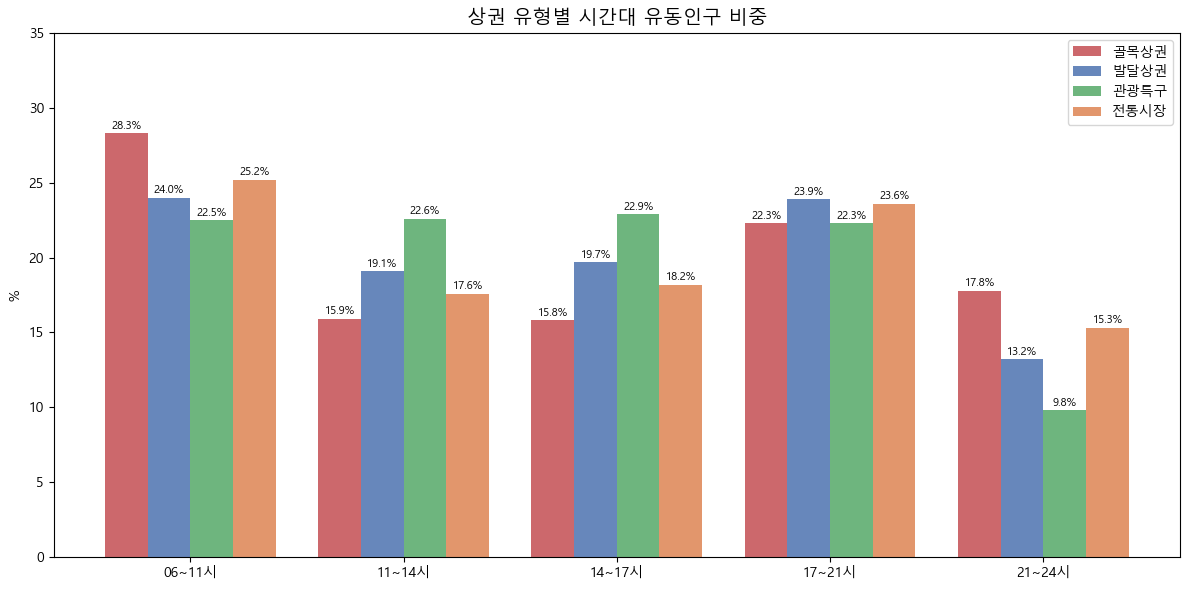

In [14]:
# ============================================
# 상권 유형별 시간대 유동인구 비중 그래프
# ============================================

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(시간대_라벨))
width = 0.2
colors = ['#C44E52', '#4C72B0', '#55A868', '#DD8452']

for i, (구분, color) in enumerate(zip(상권, colors)):
    values = df_시간대.loc[구분].values
    bars = ax.bar(x + i * width, values, width, label=구분, color=color, alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val}%', ha='center', fontsize=8)

ax.set_title('상권 유형별 시간대 유동인구 비중', fontsize=14)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(시간대_라벨)
ax.set_ylabel('%')
ax.legend()
ax.set_ylim(0, 35)

plt.tight_layout()
plt.show()